# 论文 Figure 1

In [3]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches


df_moves = pd.read_parquet(r'..\df_moves6.parquet')

In [4]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'P_model', 'S',
       'P_model(Global=10.0cp)', 'S(Global=10.0cp)', 'P_model(Global=50.0cp)',
       'S(Global=50.0cp)', 'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'Cog_Speed'],
      dtype='object')

In [5]:
df_moves['Game_Length'].head()

0    63
1    63
2    63
3    63
4    63
Name: Game_Length, dtype: int16

In [6]:
df_moves[['uid', 'Move_Idx', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5', 'Δ']].head()
# 第6行 第30行

,uid,Move_Idx,Color,E,E1,E2,E3,E4,E5,Δ
0,34,1,White,33.0,36.0,34,31,25,16,6.0
1,34,2,Black,36.0,33.0,34,34,42,48,4.0
2,34,3,White,30.0,36.0,33,27,25,20,7.0
3,34,4,Black,44.0,30.0,63,66,78,79,38.0
4,34,5,White,32.0,44.0,35,26,21,21,15.0


## 拿到uid=35 的游戏三个局面fen： Move_Index = 7, 31, 35

In [7]:
steps_str = 'e2e4,c7c6,d2d4,d7d5,e4e5,c8f5,g1f3,e7e6,f1e2,g8e7,c2c3,f5g6,a2a4,e7f5,e1g1,f8e7,a4a5,a7a6,b2b4,e8g8,b1a3,b8d7,a3c2,f7f6,g2g4,f5h6,e5f6,f8f6,g4g5,g6c2,d1c2,f6g6,h2h4,d7f6,f3e5,h6f5,e5g6,h7g6,g5f6,e7f6,e2g4,g8f7,c1f4,g6g5,h4g5,f6g5,c2d2,g5f6,g4f5,e6f5,g1g2,g7g5,f4e5,d8d7,f1h1,f7g6,e5f6,f5f4,d2d3,g6f6,h1h6,f6g7,d3h7'
moves = steps_str.split(',')
board = chess.Board()
target_indices = [7, 31, 35]
fens = {}
for i in range(len(moves)+1):
    move_idx = i+1
    if move_idx in target_indices:
        fens[move_idx] = board.fen()
    if i < len(moves):
        board.push_uci(moves[i])
for idx, fen in fens.items():
    print(f'Move_Idx {idx}----FEN: {fen}')

Move_Idx 7----FEN: rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP2PPP/RNBQKBNR w KQkq - 1 4
Move_Idx 31----FEN: r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 w - - 0 16
Move_Idx 35----FEN: r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BP2/R1B2RK1 w - - 1 18


In [8]:
class SimpleStockfishEngine:
    """保留了抓取 pv 走法的能力"""
    def __init__(self, engine_path, threads=1, multi_pv=5):
        self.engine_path = Path(engine_path)
        if not self.engine_path.exists():
            raise FileNotFoundError(f"引擎路径不存在: {engine_path}")
        
        self.process = subprocess.Popen(
            str(self.engine_path),
            universal_newlines=True,
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            bufsize=1
        )
        self._send_command("uci")
        self._wait_for("uciok")
        self._send_command(f"setoption name Threads value {threads}")
        self._send_command(f"setoption name MultiPV value {multi_pv}")
        self._send_command("isready")
        self._wait_for("readyok")
    
    def _send_command(self, command):
        self.process.stdin.write(f"{command}\n")
        self.process.stdin.flush()
    
    def _wait_for(self, text, timeout=5.0):
        start_time = time.time()
        while time.time() - start_time < timeout:
            line = self.process.stdout.readline().strip()
            if text in line:
                return line
        raise TimeoutError(f"等待'{text}'超时")
    
    def analyse(self, board, depth=18):
        fen = board.fen()
        self._send_command(f"position fen {fen}")
        self._send_command(f"go depth {depth}")
        pv_info = {} 
        
        while True:
            line = self.process.stdout.readline().strip()
            if "bestmove" in line:
                break
            if "score" in line and "multipv" in line:
                try:
                    parts = line.split()
                    mpv_id = int(parts[parts.index("multipv") + 1])
                    score_type = parts[parts.index("score") + 1]
                    score_val = int(parts[parts.index("score") + 2])
                
                    if score_type == "cp":
                        score_obj = chess.engine.Cp(score_val)
                    elif score_type == "mate":
                        score_obj = chess.engine.Mate(score_val)
                    else:
                        score_obj = chess.engine.Cp(0)
                        
                    move_name = "Unknown"
                    if "pv" in parts:
                        move_name = parts[parts.index("pv") + 1] 
                
                    pv_info[mpv_id] = {"score": score_obj, "move": move_name}
                except (ValueError, IndexError):
                    pass
        return pv_info
    
    def quit(self):
        self._send_command("quit")
        self.process.terminate()

def get_raw_cp_like_dataframe(score_obj, board, mate_cap=10000):
    """
    复刻原代码中 ComplexityAnalyzer.score_to_cp 和视角转换的逻辑。
    """
    if score_obj is None: 
        return None
        
    if isinstance(score_obj, chess.engine.Mate):
        mate_steps = score_obj.mate()
        if mate_steps > 0:
            val = mate_cap - mate_steps
        else:
            val = -mate_cap - mate_steps
    else:
        val = score_obj.score()
        
    # 视角转换：对齐你 DataFrame 里的白方视角要求
    if board.turn == chess.WHITE:
        return val
    else:
        return -val

# ================= 运行测试区 =================
if __name__ == "__main__":
    # 你的引擎路径
    ENGINE_PATH = r"C:\Users\Administrator\Desktop\stockfish-windows-x86-64-avx2\stockfish\stockfish-windows-x86-64-avx2.exe"
    
    # 你想要验证的 FEN
    fens_to_test = {
        "Move_Idx 7 (高模糊度/图c)": "rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP2PPP/RNBQKBNR w KQkq - 1 4",
        "Move_Idx 31 (低模糊度/图b)": "r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 w - - 0 16",
        "Move_Idx 35 (图a)": "r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BP2/R1B2RK1 w - - 1 18"
    }
    
    engine = SimpleStockfishEngine(ENGINE_PATH, threads=1, multi_pv=5)
    
    try:
        for name, fen_str in fens_to_test.items():
            print(f"\n[{name}]")
            print(f"原局面 FEN: {fen_str}")
            
            board = chess.Board(fen_str)
            results = engine.analyse(board, depth=18) 
            
            print(f"{'Rank':<4} | {'Move':<6} | {'DF Score':<8} | {'走子后的新 FEN'}")
            print("-" * 80)
            
            for i in range(1, 6):
                if i in results:
                    info = results[i]
                    move_str = info["move"]
                    
                    # 强行使用你 DataFrame 里的逻辑去算分
                    raw_score = get_raw_cp_like_dataframe(info["score"], board)
                    
                    # 模拟走子并拿新 FEN
                    board_copy = board.copy()
                    try:
                        board_copy.push(chess.Move.from_uci(move_str))
                        new_fen = board_copy.fen()
                    except:
                        new_fen = "Error"
                    
                    print(f"Top{i:<2} | {move_str:<6} | {str(raw_score):<8} | {new_fen}")
            
    finally:
        engine.quit()


[Move_Idx 7 (高模糊度/图c)]
原局面 FEN: rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP2PPP/RNBQKBNR w KQkq - 1 4
Rank | Move   | DF Score | 走子后的新 FEN
--------------------------------------------------------------------------------
Top1  | f1e2   | 43       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP1BPPP/RNBQK1NR b KQkq - 2 4
Top2  | g1f3   | 40       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/5N2/PPP2PPP/RNBQKB1R b KQkq - 2 4
Top3  | h2h4   | 34       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P3P/8/PPP2PP1/RNBQKBNR b KQkq - 0 4
Top4  | b1d2   | 27       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPPN1PPP/R1BQKBNR b KQkq - 2 4
Top5  | c2c3   | 26       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/2P5/PP3PPP/RNBQKBNR b KQkq - 0 4

[Move_Idx 31 (低模糊度/图b)]
原局面 FEN: r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 w - - 0 16
Rank | Move   | DF Score | 走子后的新 FEN
--------------------------------------------------------------------------------
Top1  | d1c2   | 115      | r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2Q1BP1P/R1B2RK1 b - - 0 16
To

In [9]:
def show_board_with_scores(fen, candidate_moves, board_size=400):
    """
    在 Jupyter Notebook 中优雅地显示棋盘、多色候选步箭头以及分数图例。
    包含根据用户加权公式计算的真实 Delta 值。
    """
    board = chess.Board(fen)
    
    # 5 种纯色 (绿, 蓝, 紫, 橙, 红)
    colors = ["#228B22", "#1E90FF", "#8A2BE2", "#FF8C00", "#DC143C"]
    arrows = []
    
    # === 构建高学术质感的 HTML 图例 ===
    legend_html = f"<div style='display: flex; flex-direction: column; justify-content: center; margin-left: 25px; font-family: Arial, sans-serif;'>"
    legend_html += f"<h4 style='margin-bottom: 5px; font-weight: bold;'>Stockfish Evaluation</h4>"
    legend_html += f"<div style='margin-bottom: 12px; font-size: 13px; color: #555; border-bottom: 1.5px solid #ccc; padding-bottom: 5px;'>"
    legend_html += f"Top {len(candidate_moves)} Moves (Unit: cp)</div>"
    
    # 循环添加每个走法
    for i, (uci, score) in enumerate(candidate_moves):
        color = colors[i % len(colors)]
        move = chess.Move.from_uci(uci)
        arrows.append(chess.svg.Arrow(move.from_square, move.to_square, color=color))
        
        legend_html += f"<div style='display: flex; align-items: center; margin-bottom: 8px;'>"
        legend_html += f"<div style='width: 14px; height: 14px; background-color: {color}; margin-right: 10px; border-radius: 2px;'></div>"
        legend_html += f"<span style='font-size: 14px;'>Rank {i+1} (<b>{uci}</b>): <span style='font-family: monospace;'>{score:+} cp</span></span>"
        legend_html += "</div>"
        
    # 加权 Delta 计算逻辑
    if len(candidate_moves) > 1:
        # 视角转换: White 为 1, Black 为 -1
        sign = 1 if board.turn == chess.WHITE else -1
        # 权重列表
        weights = [0.48, 0.24, 0.16, 0.12]
        
        E1 = candidate_moves[0][1]
        numerator = 0.0
        denominator = 0.0
        # 遍历 E2 到 Ek (最多到 E5)
        for i in range(1, len(candidate_moves)):
            Ek = candidate_moves[i][1]
            w_k = weights[i - 1]
            # 严格套用你的公式：w_k * (E1 - E_k) * sign
            numerator += w_k * (E1 - Ek) * sign
            denominator += w_k
            
        if denominator > 0:
            delta_val = numerator / denominator
            legend_html += f"<div style='margin-top: 10px; padding-top: 10px; border-top: 1px dashed #aaa; font-size: 14px;'>"
            legend_html += f"<b>Δ_top5:</b> {delta_val:.2f} cp"
            legend_html += "</div>"
            
    legend_html += "</div>"
    
    # 渲染带有纯色箭头的棋盘 SVG
    board_svg = chess.svg.board(board=board, arrows=arrows, size=board_size, coordinates=True)
    
    final_html = f"<div style='display: flex; flex-direction: row; align-items: center;'>{board_svg}{legend_html}</div>"
    display(HTML(final_html))

## 1. 图 (a) 素材：基础概念引入局面 (Move_Idx 35)

* **原始局面 FEN**: `r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BP2/R1B2RK1 w - - 1 18`
* **HPC 总体指标**: 当前引擎评分 (E) = `290.0`，$\Delta$ = `45.0`

| 排名 (Rank) | 候选走法 | 本地评分 (DF Score) | **HPC 评分 (E1-E5)** | 走子后的新 FEN |
| :--- | :--- | :--- | :--- | :--- |
| **Top 1** | f3e5 | 364 | **335.0** | `r2q2k1/1p2b1pp/p1p1pnrn/P2pN1P1/1P1P3P/2P5/2Q1BP2/R1B2RK1 b - - 2 18` |
| **Top 2** | e2d3 | 341 | **311.0** | `r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2PB1N2/2Q2P2/R1B2RK1 b - - 2 18` |
| **Top 3** | f1e1 | 328 | **294.0** | `r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BP2/R1B1R1K1 b - - 2 18` |
| **Top 4** | g1h1 | 285 | **255.0** | `r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BP2/R1B2R1K b - - 2 18` |
| **Top 5** | g1g2 | 269 | **243.0** | `r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BPK1/R1B2R2 b - - 2 18` |

In [10]:
#：图 (a) 素材 (Move_Idx 35)
test_fen_a = "r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BP2/R1B2RK1 w - - 1 18"
test_moves_a = [
    ("f3e5", 364), 
    ("e2d3", 341), 
    ("f1e1", 328), 
    ("g1h1", 285), 
    ("g1g2", 269)
]

print(">>> 渲染 Move_Idx 35 (图a) <<<")
show_board_with_scores(test_fen_a, test_moves_a)

>>> 渲染 Move_Idx 35 (图a) <<<


## 2. 图 (b) 素材：低模糊度局面 (Move_Idx 31)

* **原始局面 FEN**: `r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 w - - 0 16`
* **HPC 总体指标**: 当前引擎评分 (E) = `103.0`，$\Delta$ = `297.0`

| 排名 (Rank) | 候选走法 | 本地评分 (DF Score) | **HPC 评分 (E1-E5)** | 走子后的新 FEN |
| :--- | :--- | :--- | :--- | :--- |
| **Top 1** | d1c2 | 115 | **100.0** | `r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2Q1BP1P/R1B2RK1 b - - 0 16` |
| **Top 2** | d1d2 | -6 | **0.0** | `r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2bQBP1P/R1B2RK1 b - - 1 16` |
| **Top 3** | g5f6 | -303 | **-286.0** | `r2q2k1/1p1nb1pp/p1p1pP1n/P2p4/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 b - - 0 16` |
| **Top 4** | d1e1 | -404 | **-421.0** | `r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2b1BP1P/R1B1QRK1 b - - 1 16` |
| **Top 5** | g5h6 | -593 | **-506.0** | `r2q2k1/1p1nb1pp/p1p1pr1P/P2p4/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 b - - 0 16` |

In [11]:
# 图b 低模糊度局面 moveidx=31
test_fen_b = "r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 w - - 0 16"
test_moves_b = [
    ("d1c2", 115), 
    ("d1d2", -6), 
    ("g5f6", -303), 
    ("d1e1", -404), 
    ("g5h6", -593)
]

show_board_with_scores(test_fen_b, test_moves_b)

## 3. 图 (c) 素材：高模糊度局面 (Move_Idx 7)

* **原始局面 FEN**: `rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP2PPP/RNBQKBNR w KQkq - 1 4`
* **HPC 总体指标**: 当前引擎评分 (E) = `40.0`，$\Delta$ = `4.0`

| 排名 (Rank) | 候选走法 | 本地评分 (DF Score) | **HPC 评分 (E1-E5)** | 走子后的新 FEN |
| :--- | :--- | :--- | :--- | :--- |
| **Top 1** | f1e2 | 43 | **39.0** | `rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP1BPPP/RNBQK1NR b KQkq - 2 4` |
| **Top 2** | g1f3 | 40 | **38.0** | `rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/5N2/PPP2PPP/RNBQKB1R b KQkq - 2 4` |
| **Top 3** | h2h4 | 34 | **36.0** | `rn1qkbnr/pp2pppp/2p5/3pPb2/3P3P/8/PPP2PP1/RNBQKBNR b KQkq - 0 4` |
| **Top 4** | b1d2 | 27 | **34.0** | `rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPPN1PPP/R1BQKBNR b KQkq - 2 4` |
| **Top 5** | c2c3 | 26 | **25.0** | `rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/2P5/PP3PPP/RNBQKBNR b KQkq - 0 4` |

---

In [12]:
# 图c 高模糊度局面 moveidx=7
test_fen_c = "rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP2PPP/RNBQKBNR w KQkq - 1 4"
test_moves_c = [
    ("f1e1", 43), 
    ("g1f3", 40), 
    ("h2h4", 34), 
    ("b1d2", 27), 
    ("c2c3", 26)
]

show_board_with_scores(test_fen_c, test_moves_c)

## Figure 4 :      
### x-axis: game progress     
### y-axis: Δ_top5

In [13]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'P_model', 'S',
       'P_model(Global=10.0cp)', 'S(Global=10.0cp)', 'P_model(Global=50.0cp)',
       'S(Global=50.0cp)', 'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'Cog_Speed'],
      dtype='object')

In [14]:
df_moves[['Δ', 'Progress']].head()

,Δ,Progress
0,6.0,0.015873
1,4.0,0.031746
2,7.0,0.047619
3,38.0,0.063492
4,15.0,0.079365


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19008\4188166233.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_moves.groupby('Progress_Bin')['Δ'].mean().reset_index()


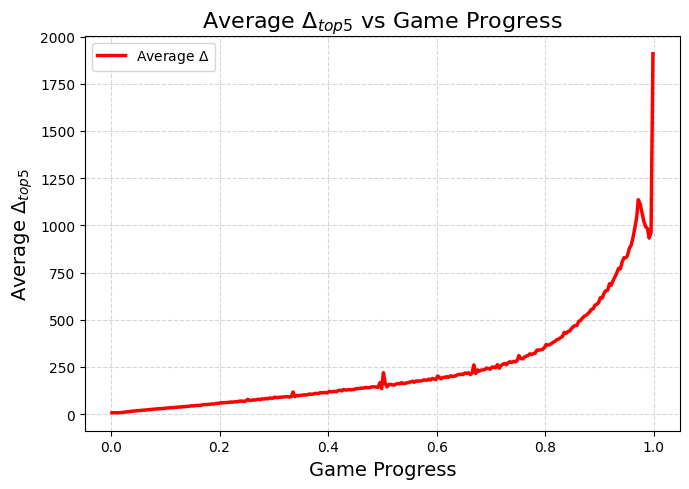

In [15]:
plt.figure(figsize=(7, 5))
df_moves['Progress_Bin'] = pd.cut(df_moves['Progress'], bins=300)
df_mean = df_moves.groupby('Progress_Bin')['Δ'].mean().reset_index()
df_mean['Progress'] = df_mean['Progress_Bin'].apply(lambda x: x.mid).astype(float)

# 画均值线
plt.plot(df_mean['Progress'], df_mean['Δ'], color='red', linewidth=2.5, label=r'Average $\Delta$')
plt.title(r'Average $\Delta_{top5}$ vs Game Progress', fontsize=16)
plt.xlabel('Game Progress', fontsize=14)
plt.ylabel(r'Average $\Delta_{top5}$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

我感觉我比较难以解释那个突然的下落是为什么    
因此重新画一个提出了强制走子的图，去看接近尾部的下滑是否还是存在

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19008\2197458634.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19008\2197458634.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = musk.groupby('Progress_Bin')[['Δ','Δi']].mean().reset_index()


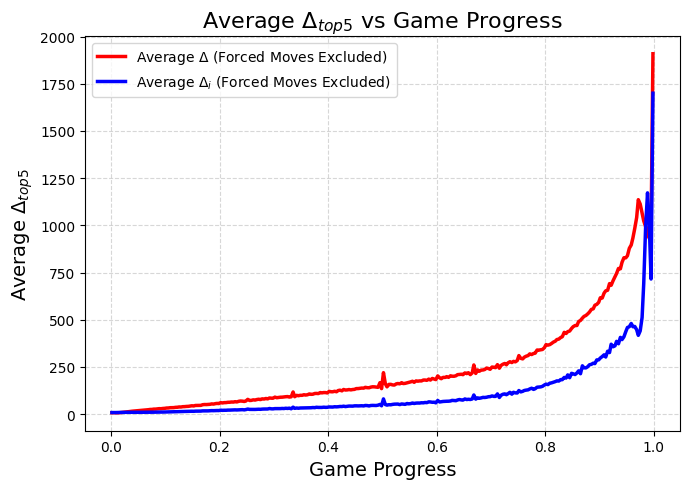

In [16]:
# Mask来剔除所有 Is_Forced == 1 的强制走子)
musk = df_moves[df_moves['Is_Forced'] != 1]

plt.figure(figsize=(7, 5))
musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)
df_mean = musk.groupby('Progress_Bin')[['Δ','Δi']].mean().reset_index()

df_mean['Progress'] = df_mean['Progress_Bin'].apply(lambda x: x.mid).astype(float)

plt.plot(df_mean['Progress'], df_mean['Δ'], color='red', linewidth=2.5, label=r'Average $\Delta$ (Forced Moves Excluded)')
plt.plot(df_mean['Progress'], df_mean['Δi'], color='blue', linewidth=2.5, label=r'Average $\Delta_i$ (Forced Moves Excluded)')

plt.title(r'Average $\Delta_{top5}$ vs Game Progress', fontsize=16)
plt.xlabel('Game Progress', fontsize=14)
plt.ylabel(r'Average $\Delta_{top5}$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5) 
plt.legend()
plt.tight_layout()
plt.show()

这里还有解释 为什么快临近终点的时候会有一个小下降    
初步猜测是和check或者checkmate有关，之前以为和forced move有关现在发现不是   具体原因探究还是看S_endgame.ipynb吧      
可能要补充判断check或者checkmate的代码

In [17]:
del musk
gc.collect()

11085

## Figure 5
### x-axis: game progress
### y-axis: P_model

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19008\2355054688.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_moves.groupby('Progress_Bin')['P_model'].mean().reset_index()


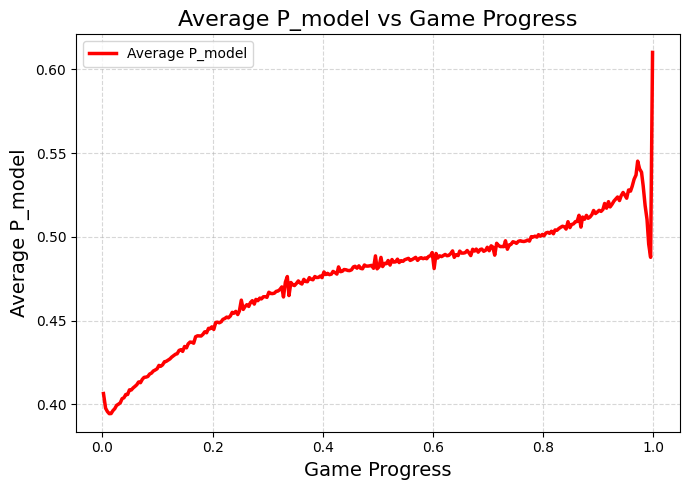

In [18]:
plt.figure(figsize=(7, 5))
df_moves['Progress_Bin'] = pd.cut(df_moves['Progress'], bins=300)
df_mean = df_moves.groupby('Progress_Bin')['P_model'].mean().reset_index()
df_mean['Progress'] = df_mean['Progress_Bin'].apply(lambda x: x.mid).astype(float)

# 画均值线
plt.plot(df_mean['Progress'], df_mean['P_model'], color='red', linewidth=2.5, label=r'Average P_model')
plt.title(r'Average P_model vs Game Progress', fontsize=16)
plt.xlabel('Game Progress', fontsize=14)
plt.ylabel(r'Average P_model', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

其实趋势和figure4差不多，因为Δ本来就和P_model有关系，Δ随游戏进程的关系也和P_model随游戏进程的关系差不多

# 组图排版

In [19]:
def save_high_res_board(fen, moves_data, filename):
    board = chess.Board(fen)
    colors = ["#228B22", "#1E90FF", "#8A2BE2", "#FF8C00", "#DC143C"]
    arrows = [chess.svg.Arrow(chess.Move.from_uci(m[0]).from_square, 
                              chess.Move.from_uci(m[0]).to_square, 
                              color=colors[i % len(colors)]) 
              for i, m in enumerate(moves_data)]
    
    # size=1200 保证了原始矢量图的内部尺寸足够大
    svg_data = chess.svg.board(board=board, arrows=arrows, size=1200, coordinates=True)
    with open(filename, "w") as f:
        f.write(svg_data)
    print(f"已保存矢量图: {filename}")

# 生成 (a)(b)(c) 的纯矢量 SVG
save_high_res_board(test_fen_a, test_moves_a, "board_a.svg")
save_high_res_board(test_fen_b, test_moves_b, "board_b.svg")
save_high_res_board(test_fen_c, test_moves_c, "board_c.svg")

已保存矢量图: board_a.svg
已保存矢量图: board_b.svg
已保存矢量图: board_c.svg


在https://cloudconvert.com/svg-to-png手动把svg图片转换为pgn格式的

<>:56: SyntaxWarning: invalid escape sequence '\D'
<>:56: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19008\2952315657.py:56: SyntaxWarning: invalid escape sequence '\D'
  ax.text(0.0, y - 0.03, f"$\Delta_{{top5}}$: {delta_val_calculated:.2f} cp", fontsize=11, fontweight='bold', va='top')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19008\2952315657.py:112: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)


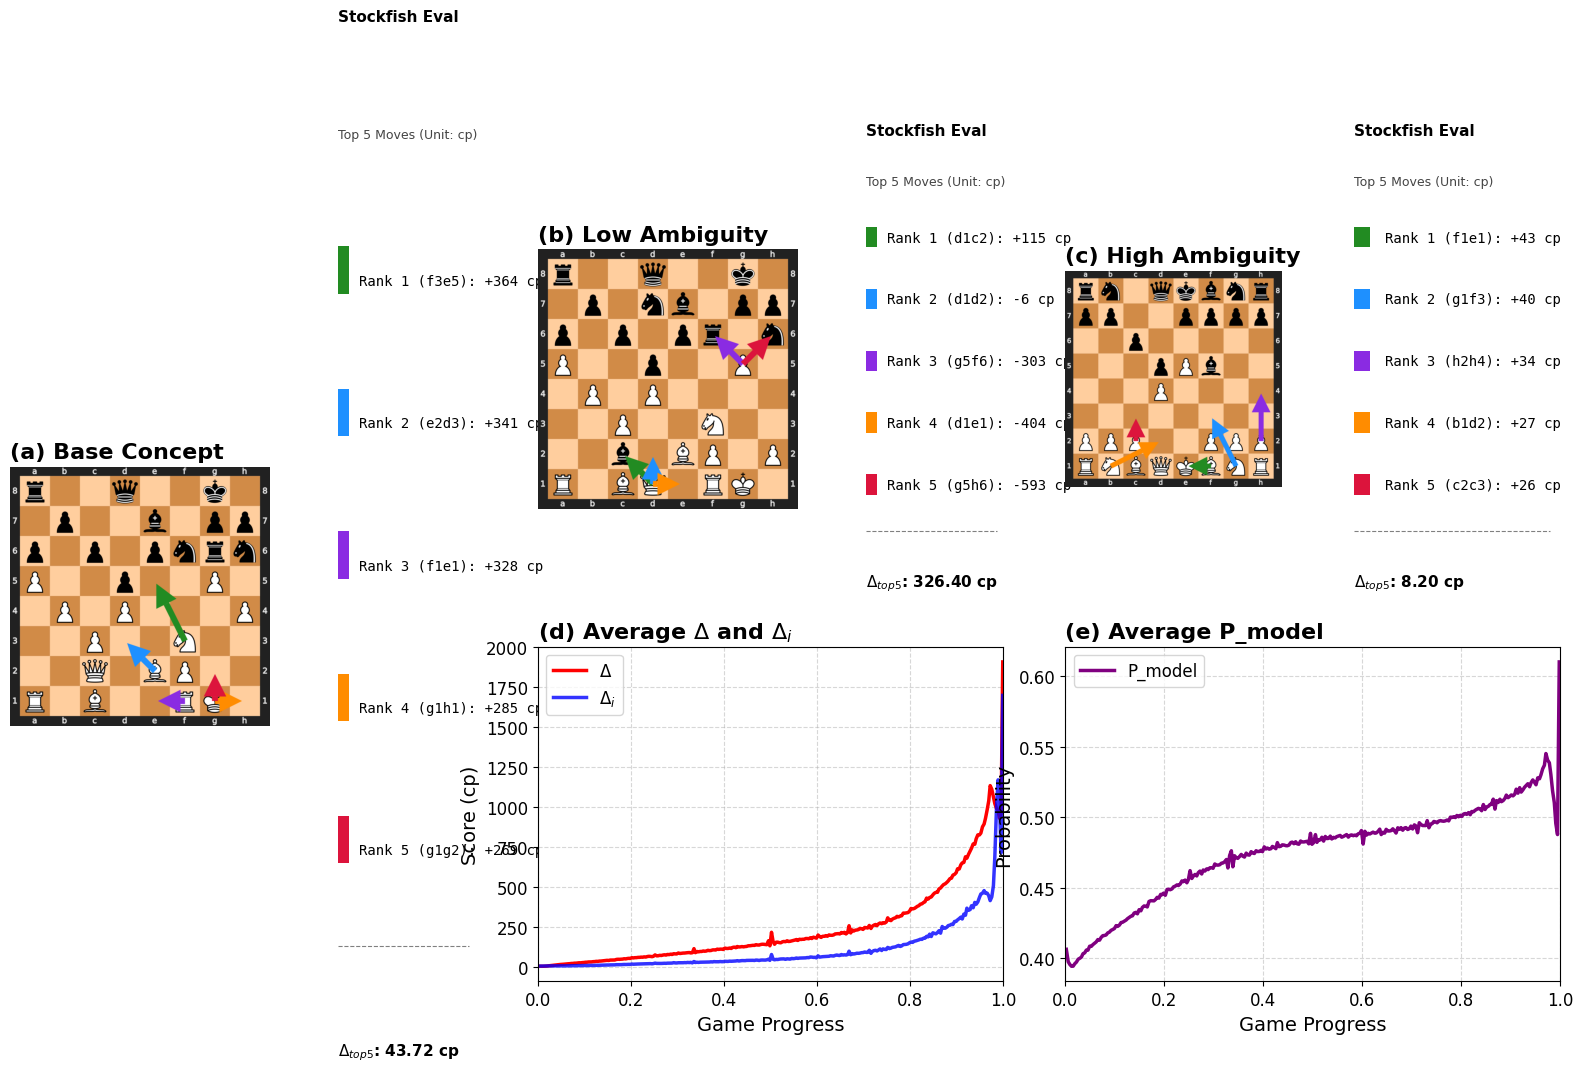

In [ ]:
TITLE_FONT = 16
LABEL_FONT = 14

def draw_native_legend_repaired(ax, candidate_moves, is_white_turn=True):
    ax.axis('off')
    colors = ["#228B22", "#1E90FF", "#8A2BE2", "#FF8C00", "#DC143C"]
    ax.text(0.0, 0.96, "Stockfish Eval", fontsize=11, fontweight='bold', va='top')
    ax.text(0.0, 0.86, f"Top {len(candidate_moves)} Moves (Unit: cp)", fontsize=9, color='#444444', va='top')
    # 循环绘制候选步
    y = 0.72
    for i, (uci, score) in enumerate(candidate_moves):
        color = colors[i % len(colors)]
        ax.add_patch(patches.Rectangle((0.0, y), 0.08, 0.04, facecolor=color, edgecolor='none'))
        ax.text(0.15, y + 0.005, f"Rank {i+1} ({uci}): {score:+} cp", fontsize=10, fontfamily='monospace', va='bottom')
        y -= 0.12 

    delta_val_calculated = np.nan # 默认值 NaN
    if len(candidate_moves) > 1:
        # 视角转换
        sign = 1 if is_white_turn else -1
        weights = [0.48, 0.24, 0.16, 0.12]
        E1 = candidate_moves[0][1]
        numerator = 0.0
        denominator = 0.0
        for i in range(1, len(candidate_moves)):
            Ek = candidate_moves[i][1]
            w_k = weights[i - 1]
            numerator += w_k * (E1 - Ek) * sign
            denominator += w_k
        if denominator > 0:
            delta_val_calculated = numerator / denominator
    ax.plot([0.0, 0.95], [y + 0.05, y + 0.05], color='gray', lw=0.8, linestyle='--')
    ax.text(0.0, y - 0.03, f"$\Delta_{{top5}}$: {delta_val_calculated:.2f} cp", fontsize=11, fontweight='bold', va='top')
fig = plt.figure(figsize=(20, 10)) # 画布调回适中尺寸
gs = gridspec.GridSpec(2, 6, figure=fig, width_ratios=[1.8, 1, 1.8, 1, 1.5, 1.5], wspace=0.3, hspace=0.3)
test_moves_a = [("f3e5", 364), ("e2d3", 341), ("f1e1", 328), ("g1h1", 285), ("g1g2", 269)]
test_moves_b = [("d1c2", 115), ("d1d2", -6), ("g5f6", -303), ("d1e1", -404), ("g5h6", -593)]
test_moves_c = [("f1e1", 43), ("g1f3", 40), ("h2h4", 34), ("b1d2", 27), ("c2c3", 26)]

# (a)
ax_a_img = fig.add_subplot(gs[0:2, 0]) # 跨越两行
ax_a_leg = fig.add_subplot(gs[0:2, 1]) # 跨越两行
ax_a_leg.axis('off')
# (b)
ax_b_img = fig.add_subplot(gs[0, 2])
ax_b_leg = fig.add_subplot(gs[0, 3])
ax_b_leg.axis('off')
# (c)
ax_c_img = fig.add_subplot(gs[0, 4])
ax_c_leg = fig.add_subplot(gs[0, 5])
ax_c_leg.axis('off')
img_configs = [(ax_a_img, 'board_a.png', '(a) Base Concept'),(ax_b_img, 'board_b.png', '(b) Low Ambiguity'),(ax_c_img, 'board_c.png', '(c) High Ambiguity')]

for ax, img_name, label in img_configs:
    ax.axis('off')
    ax.set_title(label, loc='left', fontsize=TITLE_FONT, fontweight='bold')
    try:
        ax.imshow(mpimg.imread(img_name), aspect='equal') 
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'Please convert SVG to\n{img_name}', ha='center', va='center', fontsize=12, color='red')
ax_d = fig.add_subplot(gs[1, 2:4])
ax_e = fig.add_subplot(gs[1, 4:6])
# (d) 画趋势图
musk = df_moves[df_moves['Is_Forced'] != 1]
musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)
df_mean_d = musk.groupby('Progress_Bin', observed=True)[['Δ', 'Δi']].mean().reset_index()
df_mean_d['Progress'] = df_mean_d['Progress_Bin'].apply(lambda x: x.mid).astype(float)
ax_d.plot(df_mean_d['Progress'], df_mean_d['Δ'], color='red', linewidth=2.5, label=r'$\Delta$')
ax_d.plot(df_mean_d['Progress'], df_mean_d['Δi'], color='blue', linewidth=2.5, linestyle='-', alpha=0.8, label=r'$\Delta_i$')
ax_d.set_title(r'(d) Average $\Delta$ and $\Delta_i$', loc='left', fontsize=TITLE_FONT, fontweight='bold')
ax_d.set_ylabel(r'Score (cp)', fontsize=LABEL_FONT)
ax_d.legend(loc='upper left', fontsize=LABEL_FONT-2)
# (e) 画 P_model 图
df_moves_e = df_moves
df_moves_e['Progress_Bin'] = pd.cut(df_moves_e['Progress'], bins=300)
df_mean_e = df_moves_e.groupby('Progress_Bin', observed=True)['P_model'].mean().reset_index()
df_mean_e['Progress'] = df_mean_e['Progress_Bin'].apply(lambda x: x.mid).astype(float)
ax_e.plot(df_mean_e['Progress'], df_mean_e['P_model'], color='purple', linewidth=2.5, label='P_model')
ax_e.set_title('(e) Average P_model', loc='left', fontsize=TITLE_FONT, fontweight='bold')
ax_e.set_ylabel('Probability', fontsize=LABEL_FONT)
ax_e.legend(loc='upper left', fontsize=LABEL_FONT-2)
for ax in [ax_d, ax_e]:
    ax.set_xlabel('Game Progress', fontsize=LABEL_FONT)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', labelsize=LABEL_FONT-2)
    ax.set_xlim(0, 1)
draw_native_legend_repaired(ax_a_leg, test_moves_a, is_white_turn=True) # a图是白棋走
draw_native_legend_repaired(ax_b_leg, test_moves_b, is_white_turn=True) # b图也是白棋走
draw_native_legend_repaired(ax_c_leg, test_moves_c, is_white_turn=True) # c图也是白棋走
plt.savefig('Figure1_Master_Publication_Repaired.pdf', format='pdf', bbox_inches='tight')
plt.show()

<>:39: SyntaxWarning: invalid escape sequence '\D'
<>:39: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19008\3009956839.py:39: SyntaxWarning: invalid escape sequence '\D'
  ax.text(0.0, y - 0.02, f"$\Delta_{{top5}}$: {delta_val_calculated:.2f} cp", fontsize=12, fontweight='bold', va='top')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19008\3009956839.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)


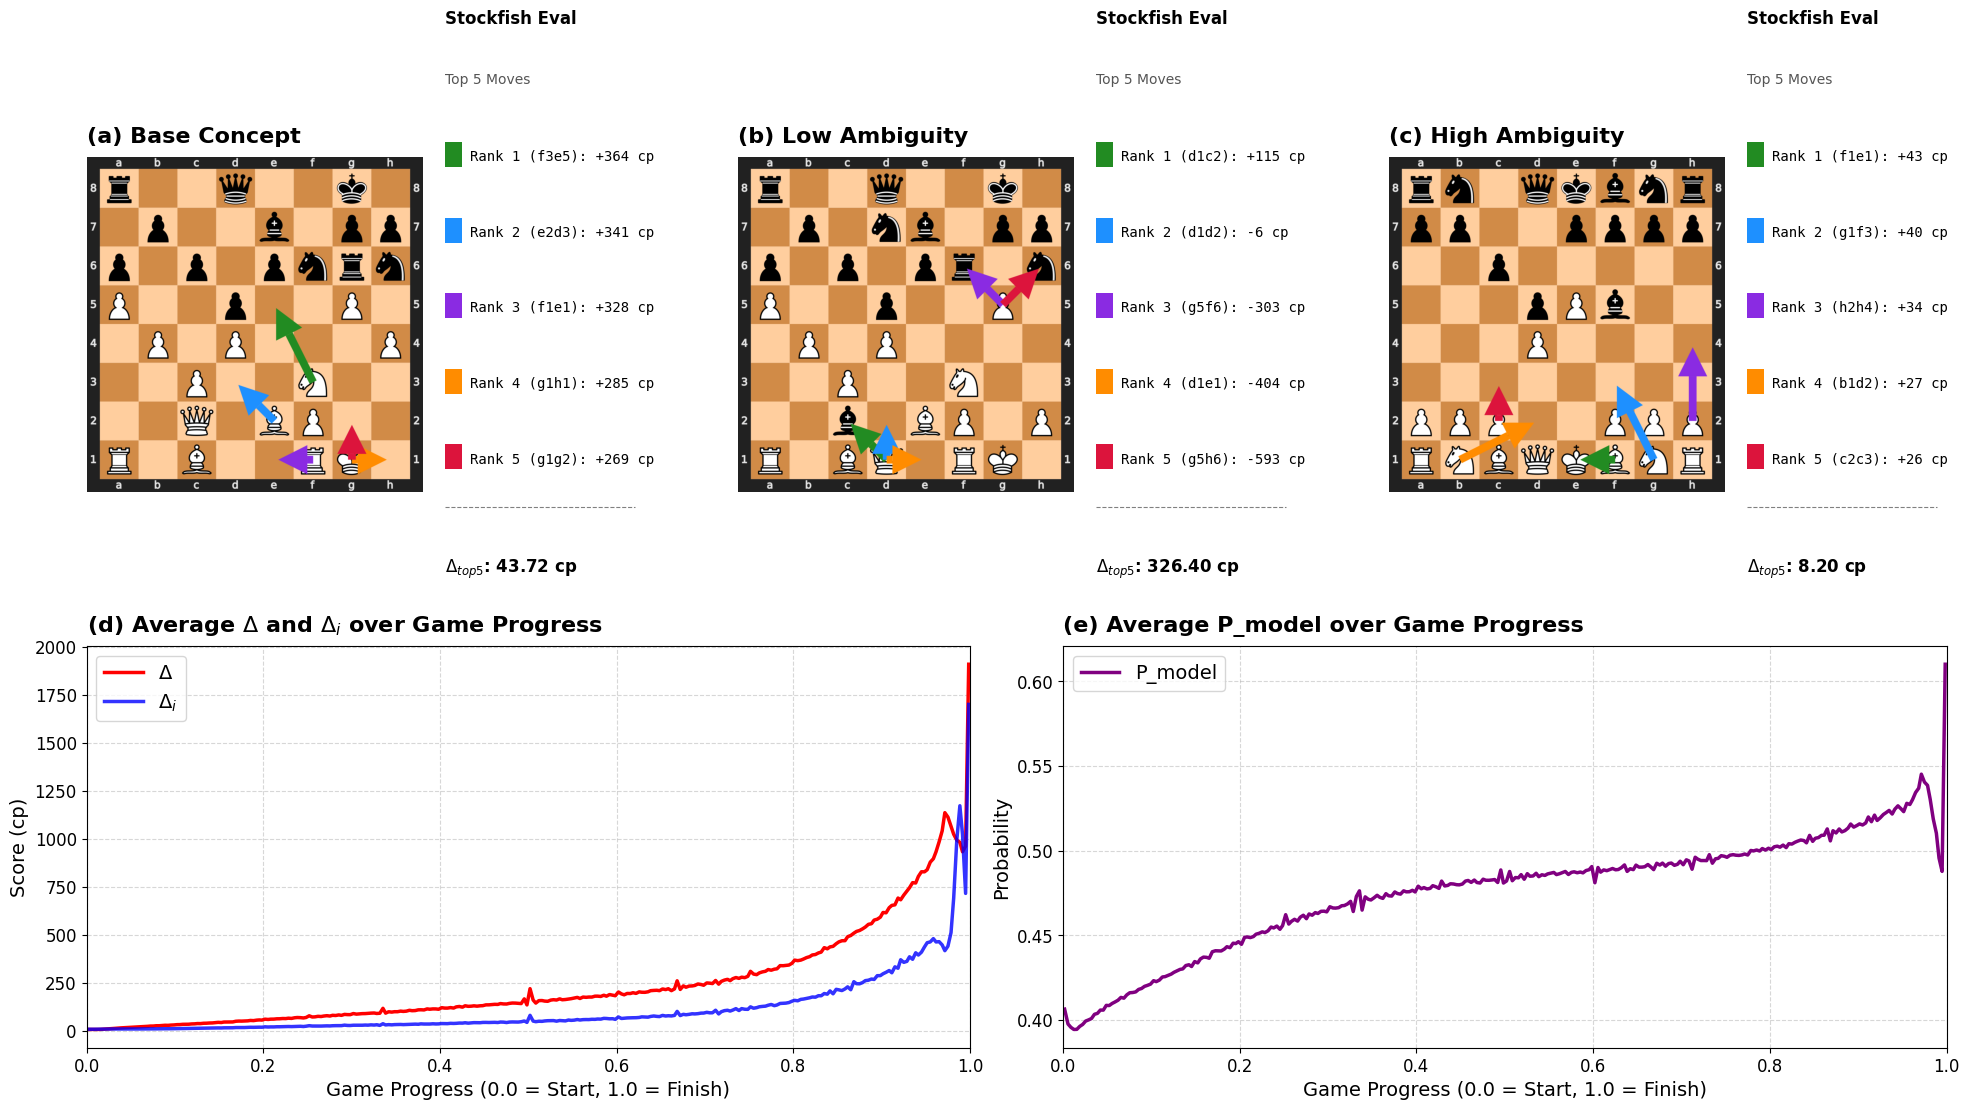

In [ ]:
TITLE_FONT = 16
LABEL_FONT = 14

def draw_native_legend_repaired(ax, candidate_moves, is_white_turn=True):
    ax.axis('off')
    colors = ["#228B22", "#1E90FF", "#8A2BE2", "#FF8C00", "#DC143C"]
    # 标题
    ax.text(0.0, 0.95, "Stockfish Eval", fontsize=12, fontweight='bold', va='top')
    ax.text(0.0, 0.85, f"Top {len(candidate_moves)} Moves", fontsize=10, color='#555555', va='top')
    # 绘制候选步
    y = 0.70
    for i, (uci, score) in enumerate(candidate_moves):
        color = colors[i % len(colors)]
        ax.add_patch(patches.Rectangle((0.0, y), 0.08, 0.04, facecolor=color, edgecolor='none'))
        ax.text(0.12, y + 0.005, f"Rank {i+1} ({uci}): {score:+} cp", fontsize=10, fontfamily='monospace', va='bottom')
        y -= 0.12 
    # 计算真实 Delta_top5
    delta_val_calculated = np.nan 
    if len(candidate_moves) > 1:
        sign = 1 if is_white_turn else -1
        weights = [0.48, 0.24, 0.16, 0.12]
        E1 = candidate_moves[0][1]
        numerator, denominator = 0.0, 0.0
        
        for i in range(1, len(candidate_moves)):
            Ek = candidate_moves[i][1]
            w_k = weights[i - 1]
            numerator += w_k * (E1 - Ek) * sign
            denominator += w_k
            
        if denominator > 0:
            delta_val_calculated = numerator / denominator
    ax.plot([0.0, 0.9], [y + 0.06, y + 0.06], color='gray', lw=0.8, linestyle='--')
    ax.text(0.0, y - 0.02, f"$\Delta_{{top5}}$: {delta_val_calculated:.2f} cp", fontsize=12, fontweight='bold', va='top')

# 开启大组图的排版 ("上 3 下 2" )
fig = plt.figure(figsize=(24, 12)) 
gs = gridspec.GridSpec(2, 6, figure=fig, wspace=0.4, hspace=0.3)
# 临时定义测试数据
test_moves_a = [("f3e5", 364), ("e2d3", 341), ("f1e1", 328), ("g1h1", 285), ("g1g2", 269)]
test_moves_b = [("d1c2", 115), ("d1d2", -6), ("g5f6", -303), ("d1e1", -404), ("g5h6", -593)]
test_moves_c = [("f1e1", 43), ("g1f3", 40), ("h2h4", 34), ("b1d2", 27), ("c2c3", 26)]
# --- 第一行：(a) 占 0-1 列，(b) 占 2-3 列，(c) 占 4-5 列 ---
gs_a = gs[0, 0:2].subgridspec(1, 2, width_ratios=[1.6, 1], wspace=0.05)
ax_a_img = fig.add_subplot(gs_a[0])
ax_a_leg = fig.add_subplot(gs_a[1])
gs_b = gs[0, 2:4].subgridspec(1, 2, width_ratios=[1.6, 1], wspace=0.05)
ax_b_img = fig.add_subplot(gs_b[0])
ax_b_leg = fig.add_subplot(gs_b[1])
gs_c = gs[0, 4:6].subgridspec(1, 2, width_ratios=[1.6, 1], wspace=0.05)
ax_c_img = fig.add_subplot(gs_c[0])
ax_c_leg = fig.add_subplot(gs_c[1])

img_configs = [(ax_a_img, 'board_a.png', '(a) Base Concept'),(ax_b_img, 'board_b.png', '(b) Low Ambiguity'),(ax_c_img, 'board_c.png', '(c) High Ambiguity')]
for ax, img_name, label in img_configs:
    ax.axis('off')
    ax.set_title(label, loc='left', fontsize=TITLE_FONT, fontweight='bold', pad=10)
    try:
        ax.imshow(mpimg.imread(img_name), aspect='equal') 
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'Please put\n{img_name}\nhere', ha='center', va='center', color='red')

draw_native_legend_repaired(ax_a_leg, test_moves_a, is_white_turn=True) 
draw_native_legend_repaired(ax_b_leg, test_moves_b, is_white_turn=True) 
draw_native_legend_repaired(ax_c_leg, test_moves_c, is_white_turn=True) 


# 第二行：(d) 占 0-2 列，(e) 占 3-5 列
ax_d = fig.add_subplot(gs[1, 0:3])
ax_e = fig.add_subplot(gs[1, 3:6])

# (d) 趋势图
musk = df_moves[df_moves['Is_Forced'] != 1]
musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)
df_mean_d = musk.groupby('Progress_Bin', observed=True)[['Δ', 'Δi']].mean().reset_index()
df_mean_d['Progress'] = df_mean_d['Progress_Bin'].apply(lambda x: x.mid).astype(float)
ax_d.plot(df_mean_d['Progress'], df_mean_d['Δ'], color='red', linewidth=2.5, label=r'$\Delta$')
ax_d.plot(df_mean_d['Progress'], df_mean_d['Δi'], color='blue', linewidth=2.5, linestyle='-', alpha=0.8, label=r'$\Delta_i$')
ax_d.set_title(r'(d) Average $\Delta$ and $\Delta_i$ over Game Progress', loc='left', fontsize=TITLE_FONT, fontweight='bold', pad=10)
ax_d.set_ylabel(r'Score (cp)', fontsize=LABEL_FONT)
ax_d.legend(loc='upper left', fontsize=LABEL_FONT)

# (e) P_model 图
df_moves_e = df_moves
df_moves_e['Progress_Bin'] = pd.cut(df_moves_e['Progress'], bins=300)
df_mean_e = df_moves_e.groupby('Progress_Bin', observed=True)['P_model'].mean().reset_index()
df_mean_e['Progress'] = df_mean_e['Progress_Bin'].apply(lambda x: x.mid).astype(float)
ax_e.plot(df_mean_e['Progress'], df_mean_e['P_model'], color='purple', linewidth=2.5, label='P_model')
ax_e.set_title('(e) Average P_model over Game Progress', loc='left', fontsize=TITLE_FONT, fontweight='bold', pad=10)
ax_e.set_ylabel('Probability', fontsize=LABEL_FONT)
ax_e.legend(loc='upper left', fontsize=LABEL_FONT)
for ax in [ax_d, ax_e]:
    ax.set_xlabel('Game Progress (0.0 = Start, 1.0 = Finish)', fontsize=LABEL_FONT)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', labelsize=LABEL_FONT-2)
    ax.set_xlim(0, 1)

plt.savefig('Figure1_Master_Publication_Final.pdf', format='pdf', bbox_inches='tight')
plt.show()